# Nonlinear Regression

This notebook reproduces the experiments in Lecture 06:

1. polynomial regression, the parametric route;
2. the local average, and why it is rough;
3. $k$-nearest neighbours;
4. kernel regression, the smooth-weight version;
5. local linear regression as weighted least squares;
6. the curse of dimensionality;
7. choosing the complexity knob by cross-validation.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/06-nonlinear-regression/'
for _name in ['Auto.csv', 'Wage.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 26506
rng = np.random.default_rng(SEED)
wage = pd.read_csv('Wage.csv')
age = wage['age'].to_numpy(float)
response = wage['wage'].to_numpy(float)
grid = np.linspace(age.min(), age.max(), 300)
print('Wage rows:', len(wage), '| age range:', age.min(), '-', age.max())

Wage rows: 3000 | age range: 18.0 - 80.0


## 1. Polynomial regression from scratch

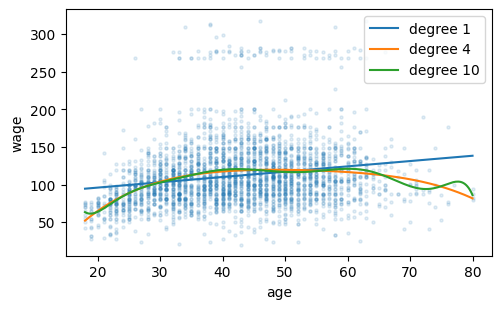

In [2]:
center, scale = age.mean(), age.std()

def polynomial_design(x, degree, center=center, scale=scale):
    z = (x-center)/scale
    return np.column_stack([z**j for j in range(degree+1)])

def polynomial_fit(x, y, degree, center=center, scale=scale):
    return np.linalg.lstsq(polynomial_design(x, degree, center, scale), y, rcond=None)[0]

plt.figure(figsize=(5.5, 3.2))
plt.scatter(age, response, s=5, alpha=.12)
for degree in (1, 4, 10):
    beta = polynomial_fit(age, response, degree)
    plt.plot(grid, polynomial_design(grid, degree)@beta, label=f'degree {degree}')
plt.xlabel('age'); plt.ylabel('wage'); plt.legend();

## 2. The local average

Assume only that $m$ is continuous. Then to estimate $m(x)$ we can average the
responses of the rows whose $x_i$ lie within $h$ of $x$.

at age 40 with h=5: 969 of 3000 rows, estimate 118.5


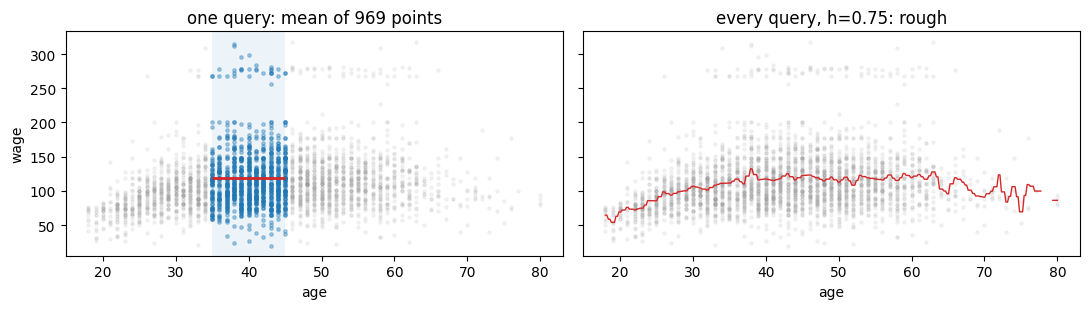

In [3]:
def local_average(x_train, y_train, query, h):
    out = np.full(len(query), np.nan)
    for j, q in enumerate(query):
        inside = np.abs(x_train-q) <= h
        if inside.any():
            out[j] = y_train[inside].mean()
    return out

inside_40 = np.abs(age-40) <= 5
print(f'at age 40 with h=5: {inside_40.sum()} of {len(age)} rows, estimate {response[inside_40].mean():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
axes[0].scatter(age[~inside_40], response[~inside_40], s=5, alpha=.10, color='0.6')
axes[0].scatter(age[inside_40], response[inside_40], s=6, alpha=.35)
axes[0].axvspan(35, 45, alpha=.08)
axes[0].hlines(response[inside_40].mean(), 35, 45, lw=2, color='C3')
axes[0].set(title=f'one query: mean of {inside_40.sum()} points', xlabel='age', ylabel='wage')
axes[1].scatter(age, response, s=5, alpha=.10, color='0.6')
axes[1].plot(grid, local_average(age, response, grid, .75), lw=1, color='C3')
axes[1].set(title='every query, h=0.75: rough', xlabel='age')
plt.tight_layout();

## 3. $k$-nearest neighbours

A fixed radius misbehaves where the data are uneven. Fixing the *count* instead
lets the neighbourhood widen automatically where rows are scarce.

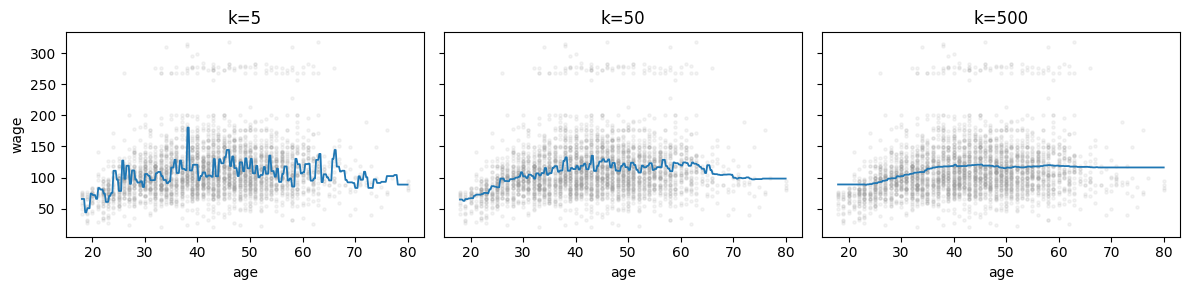

In [4]:
def knn_regression(x_train, y_train, query, k):
    order = np.argsort(np.abs(query[:, None]-x_train[None, :]), axis=1)
    return y_train[order[:, :k]].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.0), sharey=True)
for ax, k in zip(axes, (5, 50, 500)):
    ax.scatter(age, response, s=5, alpha=.10, color='0.6')
    ax.plot(grid, knn_regression(age, response, grid, k), lw=1.3)
    ax.set(title=f'k={k}', xlabel='age')
axes[0].set_ylabel('wage'); plt.tight_layout();

## 4. Kernel regression

Both estimators above use a hard cutoff: a point just inside counts fully, one
just outside not at all. Replacing the indicator by a weight that decays with
distance gives the Nadaraya--Watson estimator.

box kernel equals local average: True


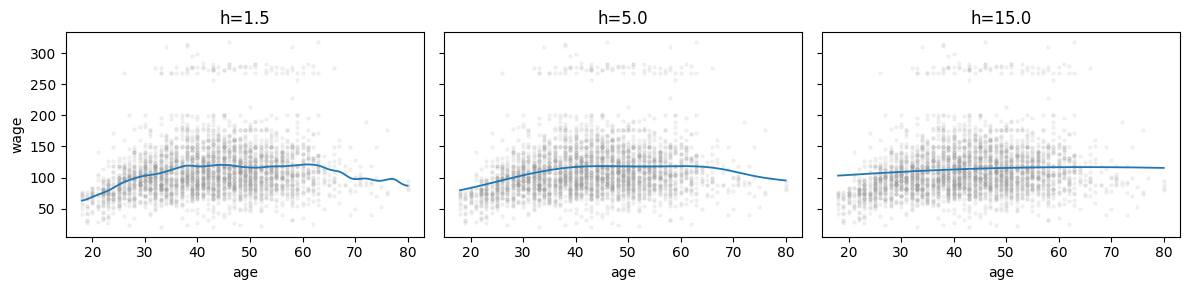

In [5]:
def kernel_regression(x_train, y_train, query, h):
    weights = np.exp(-.5*((query[:, None]-x_train[None, :])/h)**2)
    return (weights@y_train)/weights.sum(1)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.0), sharey=True)
for ax, h in zip(axes, (1.5, 5.0, 15.0)):
    ax.scatter(age, response, s=5, alpha=.10, color='0.6')
    ax.plot(grid, kernel_regression(age, response, grid, h), lw=1.3)
    ax.set(title=f'h={h}', xlabel='age')
axes[0].set_ylabel('wage'); plt.tight_layout();

# The box kernel recovers the local average exactly.
box = np.abs(grid[:, None]-age[None, :]) <= 5
print('box kernel equals local average:',
      np.allclose((box@response)/box.sum(1), local_average(age, response, grid, 5.)))

## 5. Local linear regression

Fitting a constant biases the estimate near a boundary, where the neighbours all
lie on one side. Fitting a local *line* is weighted least squares:
$\widehat c = (Z^\top W Z)^{-1} Z^\top W y$ with $\widehat m(x_0)=\widehat a$.

mean gap at the left boundary: -16.13


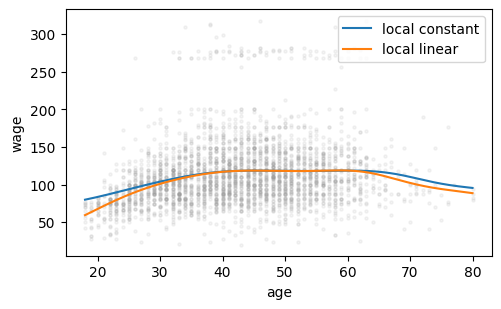

In [6]:
def local_linear(x_train, y_train, query, h):
    out = np.empty(len(query))
    for j, q in enumerate(query):
        w = np.exp(-.5*((x_train-q)/h)**2)
        Z = np.column_stack([np.ones_like(x_train), x_train-q])
        ZtW = Z.T*w
        out[j] = np.linalg.solve(ZtW@Z, ZtW@y_train)[0]   # the intercept is the prediction
    return out

plt.figure(figsize=(5.5, 3.2))
plt.scatter(age, response, s=5, alpha=.10, color='0.6')
plt.plot(grid, kernel_regression(age, response, grid, 5.), label='local constant')
plt.plot(grid, local_linear(age, response, grid, 5.), label='local linear')
plt.xlabel('age'); plt.ylabel('wage'); plt.legend()
edge = grid < 22
print('mean gap at the left boundary:',
      round(float(np.mean(local_linear(age,response,grid,5.)[edge]
                          - kernel_regression(age,response,grid,5.)[edge])), 2))

## 6. The curse of dimensionality

The response depends on the first feature only; the rest are noise. Local
methods need neighbours, and in high dimensions there are none nearby.

 p  knn_MSE  linear_MSE
 1    0.011       0.029
 2    0.034       0.030
 3    0.080       0.032
 4    0.139       0.033
 5    0.186       0.035
10    0.380       0.044
20    0.545       0.075

KNN error grows 51x from p=1 to p=20, linear 2.6x


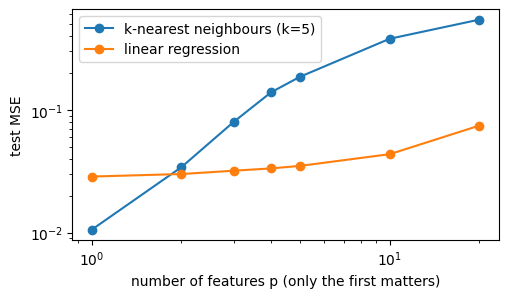

In [7]:
# seed 265 matches the slide figure
def curse_experiment(dims=(1,2,3,4,5,10,20), n_train=50, n_test=500, reps=60, k=5, seed=265):
    gen = np.random.default_rng(seed)
    f = lambda Z: np.sin(2.0*Z[:,0]) + .3*Z[:,0]
    rows = []
    for p in dims:
        lin_r, knn_r = [], []
        for _ in range(reps):
            Xtr, Xte = gen.uniform(-1,1,(n_train,p)), gen.uniform(-1,1,(n_test,p))
            ytr, yte = f(Xtr) + .2*gen.standard_normal(n_train), f(Xte)
            A = np.column_stack([np.ones(n_train), Xtr])
            beta = np.linalg.lstsq(A, ytr, rcond=None)[0]
            lin_r.append(np.mean((yte - np.column_stack([np.ones(n_test), Xte])@beta)**2))
            d = np.linalg.norm(Xte[:,None,:]-Xtr[None,:,:], axis=2)
            knn_r.append(np.mean((yte - ytr[np.argsort(d,axis=1)[:,:k]].mean(1))**2))
        rows.append((p, np.mean(knn_r), np.mean(lin_r)))
    return pd.DataFrame(rows, columns=['p','knn_MSE','linear_MSE'])

curse = curse_experiment()
plt.figure(figsize=(5.5, 3.0))
plt.loglog(curse.p, curse.knn_MSE, 'o-', label='k-nearest neighbours (k=5)')
plt.loglog(curse.p, curse.linear_MSE, 'o-', label='linear regression')
plt.xlabel('number of features p (only the first matters)'); plt.ylabel('test MSE'); plt.legend()
print(curse.round(3).to_string(index=False))
print(f"\nKNN error grows {curse.knn_MSE.iloc[-1]/curse.knn_MSE.iloc[0]:.0f}x from p=1 to p=20, "
      f"linear {curse.linear_MSE.iloc[-1]/curse.linear_MSE.iloc[0]:.1f}x")

## 7. Choosing the knob by cross-validation

Degree, $k$, and $h$ are all chosen the same way $\lambda$ was chosen in
Lecture 04: cross-validate on the training rows, take the smallest average
score, then touch the test set once.

In [8]:
order = rng.permutation(len(age))
cut = int(.75*len(order))
train_idx, test_idx = order[:cut], order[cut:]
x_tr, y_tr = age[train_idx], response[train_idx]
x_te, y_te = age[test_idx], response[test_idx]

def cross_validate(fit_predict, values, K=5):
    folds = np.array_split(rng.permutation(len(x_tr)), K)
    rows = []
    for v in values:
        scores = []
        for f in range(K):
            val = folds[f]
            tr = np.concatenate([folds[g] for g in range(K) if g != f])
            pred = fit_predict(x_tr[tr], y_tr[tr], x_tr[val], v)
            scores.append(np.mean((y_tr[val]-pred)**2))
        rows.append((v, np.mean(scores)))
    return pd.DataFrame(rows, columns=['value','cv_MSE'])

poly_cv = cross_validate(lambda xa, ya, xb, d: polynomial_design(xb, d)@polynomial_fit(xa, ya, d),
                         range(1, 11))
knn_cv  = cross_validate(lambda xa, ya, xb, k: knn_regression(xa, ya, xb, k),
                         [2, 5, 10, 25, 50, 100, 200, 400])
kern_cv = cross_validate(lambda xa, ya, xb, h: kernel_regression(xa, ya, xb, h),
                         [1., 2., 3., 5., 8., 12., 20., 40.])

for name, table in [('degree', poly_cv), ('k', knn_cv), ('h', kern_cv)]:
    best = table.loc[table.cv_MSE.idxmin()]
    print(f'{name:7s} chosen = {best.value:<6g}  CV MSE = {best.cv_MSE:.1f}')

degree  chosen = 4       CV MSE = 1546.9
k       chosen = 200     CV MSE = 1566.9
h       chosen = 3       CV MSE = 1552.7


In [9]:
# Refit each at its chosen value on all training rows, then score the test set once.
best_degree = int(poly_cv.loc[poly_cv.cv_MSE.idxmin(),'value'])
best_k      = int(knn_cv.loc[knn_cv.cv_MSE.idxmin(),'value'])
best_h      = float(kern_cv.loc[kern_cv.cv_MSE.idxmin(),'value'])

final = {
    f'polynomial (degree {best_degree})': polynomial_design(x_te, best_degree)@polynomial_fit(x_tr, y_tr, best_degree),
    f'k-nearest neighbours (k={best_k})': knn_regression(x_tr, y_tr, x_te, best_k),
    f'kernel regression (h={best_h:g})':  kernel_regression(x_tr, y_tr, x_te, best_h),
    'constant baseline':                  np.full(len(x_te), y_tr.mean()),
}
pd.DataFrame({'test MSE': {k: np.mean((y_te-v)**2) for k, v in final.items()}}).round(1)

,test MSE
polynomial (degree 4),1740.3
k-nearest neighbours (k=200),1744.1
kernel regression (h=3),1735.6
constant baseline,1887.1


## Library comparison

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsRegressor

library = make_pipeline(PolynomialFeatures(4), LinearRegression()).fit(x_tr[:, None], y_tr)
scratch = polynomial_design(x_te, 4)@polynomial_fit(x_tr, y_tr, 4)
print('polynomial, max difference:', np.max(np.abs(library.predict(x_te[:, None])-scratch)))
assert np.allclose(library.predict(x_te[:, None]), scratch, atol=1e-6)

lib_knn = KNeighborsRegressor(n_neighbors=best_k).fit(x_tr[:, None], y_tr)
print('knn, max difference:', np.max(np.abs(lib_knn.predict(x_te[:, None])
                                            - knn_regression(x_tr, y_tr, x_te, best_k))))

polynomial, max difference: 1.4833976536010596e-07
knn, max difference: 2.8377960856262376


## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [11]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '06-nonlinear-regression'
NOTES = COURSE / 'lectures' / 'figures'

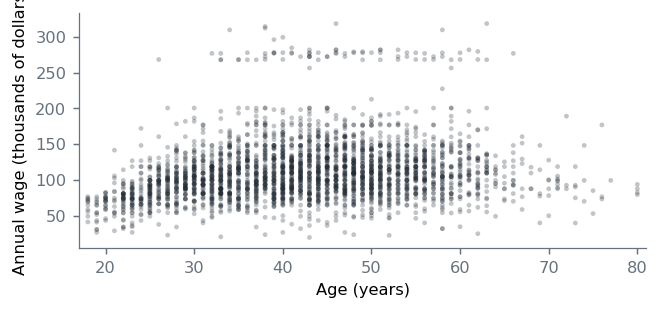

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/wage-data.pdf')

In [12]:
from __future__ import annotations

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle





SEED = 265
rng = np.random.default_rng(SEED)


def standardized(x: np.ndarray) -> tuple[np.ndarray, float, float]:
    center, scale = x.mean(), x.std()
    return (x - center) / scale, center, scale


def polynomial_fit(
    x: np.ndarray, y: np.ndarray, grid: np.ndarray, degree: int
) -> np.ndarray:
    z, center, scale = standardized(x)
    coef = np.polyfit(z, y, degree)
    return np.polyval(coef, (grid - center) / scale)


def kernel_fit(
    x: np.ndarray, y: np.ndarray, grid: np.ndarray, bandwidth: float
) -> np.ndarray:
    weights = np.exp(-0.5 * ((grid[:, None] - x[None, :]) / bandwidth) ** 2)
    return (weights @ y) / np.maximum(weights.sum(axis=1), 1e-12)


def wage_points(ax: plt.Axes, *, alpha: float = 0.23) -> None:
    ax.scatter(
        x_wage,
        y_wage,
        s=7,
        color=INK,
        alpha=alpha,
        edgecolors="none",
        rasterized=True,
        label="observed workers",
    )


wage = pd.read_csv('Wage.csv')
x_wage = wage["age"].to_numpy(float)
y_wage = wage["wage"].to_numpy(float)
age_grid = np.linspace(x_wage.min(), x_wage.max(), 300)


# Raw observations appear before any fitted model is introduced.
fig, ax = plt.subplots(figsize=FULL_TALL)
wage_points(ax, alpha=0.27)
ax.set(xlabel="Age (years)", ylabel="Annual wage (thousands of dollars)")
ax.set_xlim(17, 81)
save(fig, OUT / "wage-data.pdf", OUT / "wage-data.svg")

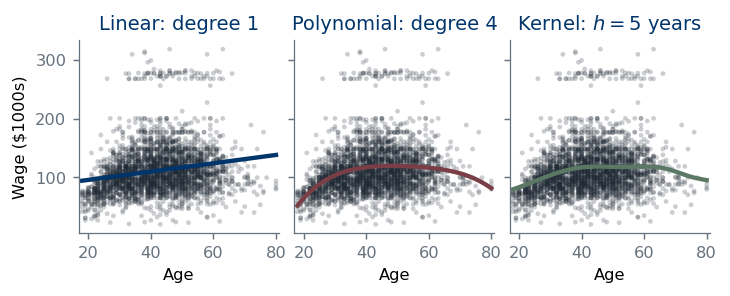

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/model-families.pdf')

In [13]:
# The first fitted comparison is shown only after each family has been defined.
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
fits = [
    (polynomial_fit(x_wage, y_wage, age_grid, 1), "Linear: degree 1", BLUE),
    (polynomial_fit(x_wage, y_wage, age_grid, 4), "Polynomial: degree 4", RED),
    (kernel_fit(x_wage, y_wage, age_grid, 5.0), "Kernel: $h=5$ years", GREEN),
]
for ax, (fit, title, color) in zip(axes, fits):
    wage_points(ax, alpha=0.23)
    ax.plot(age_grid, fit, color=color, linewidth=2.4)
    ax.set(title=title, xlabel="Age")
    ax.set_xlim(17, 81)
axes[0].set_ylabel("Wage ($1000s)")
fig.tight_layout(w_pad=0.55)
save(fig, OUT / "model-families.pdf", OUT / "model-families.svg")

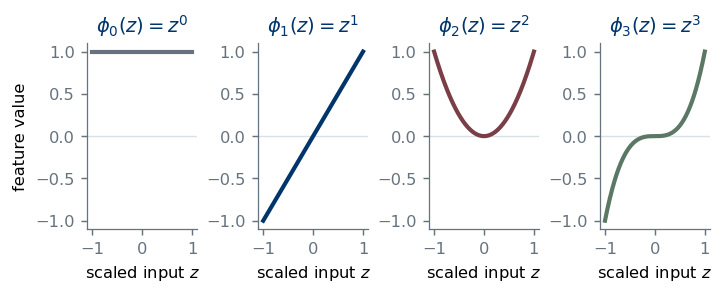

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/polynomial-basis.pdf')

In [14]:
# Fixed polynomial features on a comparable input domain.
z = np.linspace(-1, 1, 250)
fig, axes = plt.subplots(1, 4, figsize=FULL_TALL, sharex=True)
for degree, ax, color in zip(range(4), axes, [MUTED, BLUE, RED, GREEN]):
    ax.axhline(0, color=RULE, linewidth=0.8)
    ax.plot(z, z**degree, color=color, linewidth=2.3)
    ax.set_title(rf"$\phi_{degree}(z)=z^{degree}$")
    ax.set_xlabel("scaled input $z$")
    ax.set_xticks([-1, 0, 1])
    ax.set_ylim(-1.1, 1.1)
axes[0].set_ylabel("feature value")
fig.tight_layout(w_pad=0.55)
save(fig, OUT / "polynomial-basis.pdf", OUT / "polynomial-basis.svg")

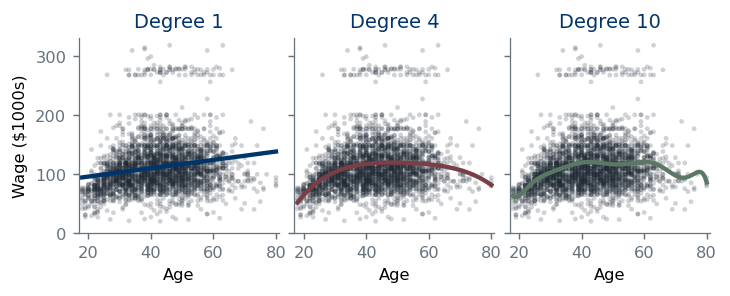

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/polynomial-fits.pdf')

In [15]:
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, degree, color in zip(axes, [1, 4, 10], [BLUE, RED, GREEN]):
    wage_points(ax, alpha=0.21)
    ax.plot(
        age_grid,
        polynomial_fit(x_wage, y_wage, age_grid, degree),
        color=color,
        linewidth=2.4,
    )
    ax.set(title=f"Degree {degree}", xlabel="Age")
    ax.set_xlim(17, 81)
    ax.set_ylim(0, 330)
axes[0].set_ylabel("Wage ($1000s)")
fig.tight_layout(w_pad=0.55)
save(fig, OUT / "polynomial-fits.pdf", OUT / "polynomial-fits.svg")

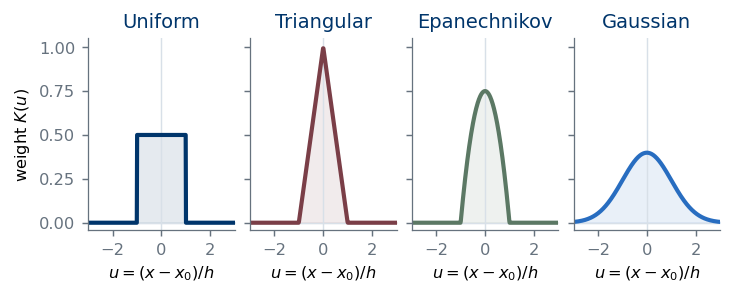

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/common-kernels.pdf')

In [16]:
# Four common nonnegative, symmetric kernel shapes.
u = np.linspace(-3.2, 3.2, 500)
kernels = [
    ("Uniform", 0.5 * (np.abs(u) <= 1), BLUE),
    ("Triangular", np.maximum(1 - np.abs(u), 0), RED),
    ("Epanechnikov", 0.75 * np.maximum(1 - u**2, 0), GREEN),
    ("Gaussian", np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi), BLUE_BRIGHT),
]
fig, axes = plt.subplots(1, 4, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, (name, values, color) in zip(axes, kernels):
    ax.axhline(0, color=RULE, linewidth=0.8)
    ax.axvline(0, color=RULE, linewidth=0.8)
    ax.plot(u, values, color=color, linewidth=2.3)
    ax.fill_between(u, values, color=color, alpha=0.10)
    ax.set(title=name, xlabel="$u=(x-x_0)/h$", xlim=(-3, 3), ylim=(-0.04, 1.05))
    ax.set_xticks([-2, 0, 2])
axes[0].set_ylabel("weight $K(u)$")
fig.tight_layout(w_pad=0.55)
save(fig, OUT / "common-kernels.pdf", OUT / "common-kernels.svg")

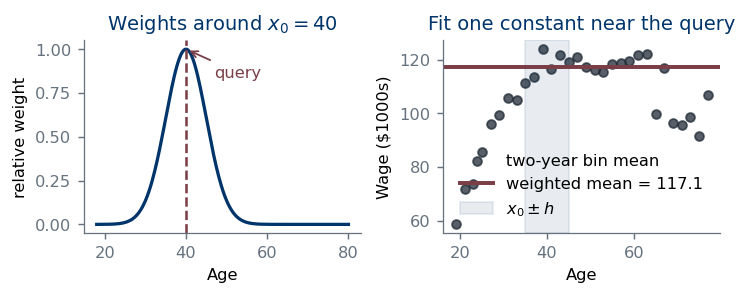

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/local-constant.pdf')

In [17]:
# Local-constant fitting at one query point, using binned means only for
# legibility; the estimate itself uses every observed row.
x0, h = 40.0, 5.0
weights = np.exp(-0.5 * ((x_wage - x0) / h) ** 2)
local_mean = float(weights @ y_wage / weights.sum())
bins = np.arange(18, 82, 2)
centers = (bins[:-1] + bins[1:]) / 2
ids = np.digitize(x_wage, bins) - 1
bin_means = np.array(
    [y_wage[ids == j].mean() if np.any(ids == j) else np.nan for j in range(len(centers))]
)

fig, axes = plt.subplots(1, 2, figsize=FULL_TALL)
axes[0].plot(age_grid, np.exp(-0.5 * ((age_grid - x0) / h) ** 2), color=BLUE)
axes[0].axvline(x0, color=RED, linestyle="--", linewidth=1.4)
axes[0].set(xlabel="Age", ylabel="relative weight", title="Weights around $x_0=40$")
axes[0].annotate("query", (x0, 1), xytext=(47, 0.84), arrowprops={"arrowstyle": "->", "color": RED}, color=RED)
axes[1].scatter(centers, bin_means, s=24, color=INK, alpha=0.75, label="two-year bin mean")
axes[1].axhline(local_mean, color=RED, linewidth=2.2, label=rf"weighted mean = {local_mean:.1f}")
axes[1].axvspan(x0 - h, x0 + h, color=BLUE, alpha=0.09, label="$x_0\pm h$")
axes[1].set(xlabel="Age", ylabel="Wage ($1000s)", title="Fit one constant near the query")
axes[1].legend(loc="lower center")
fig.tight_layout(w_pad=1.0)
save(fig, OUT / "local-constant.pdf", OUT / "local-constant.svg")

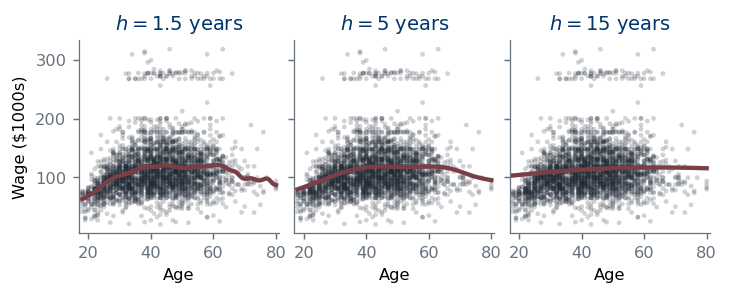

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/bandwidth-sequence.pdf')

In [18]:
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, bandwidth in zip(axes, [1.5, 5.0, 15.0]):
    wage_points(ax, alpha=0.21)
    ax.plot(age_grid, kernel_fit(x_wage, y_wage, age_grid, bandwidth), color=RED, linewidth=2.4)
    ax.set(title=f"$h={bandwidth:g}$ years", xlabel="Age")
    ax.set_xlim(17, 81)
axes[0].set_ylabel("Wage ($1000s)")
fig.tight_layout(w_pad=0.55)
save(fig, OUT / "bandwidth-sequence.pdf", OUT / "bandwidth-sequence.svg")

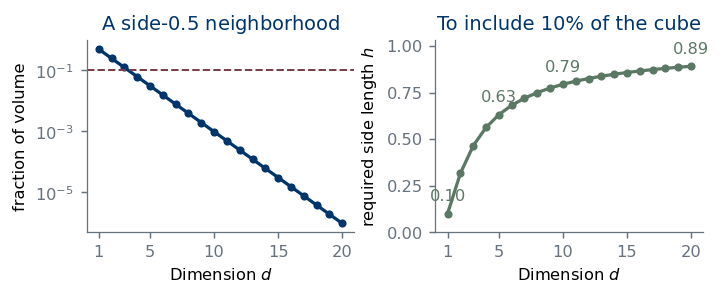

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/curse-volume.pdf')

In [19]:
# Quantify why a local neighborhood becomes nonlocal in many dimensions.
dims = np.arange(1, 21)
side_for_ten_percent = 0.1 ** (1 / dims)
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL)
axes[0].plot(dims, 0.5**dims, color=BLUE, marker="o", markersize=3.5)
axes[0].set_yscale("log")
axes[0].set(xlabel="Dimension $d$", ylabel="fraction of volume", title="A side-$0.5$ neighborhood", xticks=[1, 5, 10, 15, 20])
axes[0].axhline(0.1, color=RED, linestyle="--", linewidth=1.1)
axes[1].plot(dims, side_for_ten_percent, color=GREEN, marker="o", markersize=3.5)
axes[1].set(xlabel="Dimension $d$", ylabel="required side length $h$", title="To include 10% of the cube", xticks=[1, 5, 10, 15, 20], ylim=(0, 1.03))
for d in [1, 5, 10, 20]:
    axes[1].annotate(f"{side_for_ten_percent[d-1]:.2f}", (d, side_for_ten_percent[d-1]), xytext=(0, 7), textcoords="offset points", ha="center", color=GREEN)
fig.tight_layout(w_pad=1.0)
save(fig, OUT / "curse-volume.pdf", OUT / "curse-volume.svg")

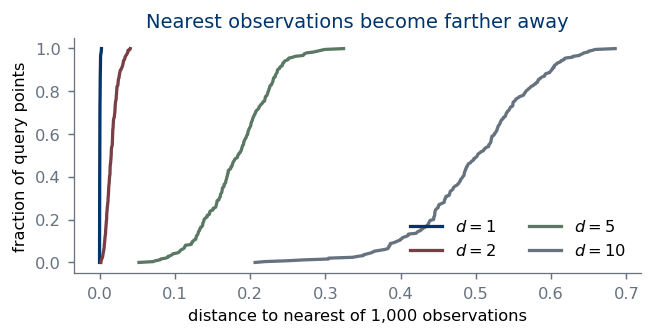

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/nearest-distance.pdf')

In [20]:
# Empirical nearest-neighbor distance distribution in a unit cube.
fig, ax = plt.subplots(figsize=FULL_TALL)
for d, color in zip([1, 2, 5, 10], [BLUE, RED, GREEN, MUTED]):
    train = rng.uniform(size=(1000, d))
    query = rng.uniform(size=(250, d))
    distances = np.sqrt(((query[:, None, :] - train[None, :, :]) ** 2).sum(axis=2)).min(axis=1)
    sorted_d = np.sort(distances)
    ax.plot(sorted_d, np.linspace(0, 1, len(sorted_d), endpoint=False), color=color, label=f"$d={d}$")
ax.set(xlabel="distance to nearest of 1,000 observations", ylabel="fraction of query points", title="Nearest observations become farther away")
ax.legend(loc="lower right", ncol=2)
save(fig, OUT / "nearest-distance.pdf", OUT / "nearest-distance.svg")

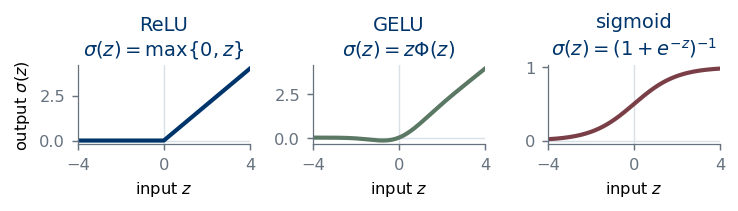

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/activation-functions.pdf')

In [21]:
# Three activation functions used in neural networks.  The exact GELU is
# z Phi(z), where Phi is the standard normal CDF.
activation_grid = np.linspace(-4, 4, 600)
relu = np.maximum(activation_grid, 0)
gelu = 0.5 * activation_grid * (
    1 + np.array([math.erf(value / np.sqrt(2)) for value in activation_grid])
)
sigmoid = 1 / (1 + np.exp(-activation_grid))
fig, axes = plt.subplots(1, 3, figsize=FULL_SHORT, sharex=True)
for ax, values, title, formula, color in zip(
    axes,
    [relu, gelu, sigmoid],
    ["ReLU", "GELU", "sigmoid"],
    [
        r"$\sigma(z)=\max\{0,z\}$",
        r"$\sigma(z)=z\Phi(z)$",
        r"$\sigma(z)=(1+e^{-z})^{-1}$",
    ],
    [BLUE, GREEN, RED],
):
    ax.axhline(0, color=RULE, linewidth=0.8)
    ax.axvline(0, color=RULE, linewidth=0.8)
    ax.plot(activation_grid, values, color=color, linewidth=2.3)
    ax.set(title=f"{title}\n{formula}", xlabel="input $z$", xlim=(-4, 4))
    ax.set_xticks([-4, 0, 4])
axes[0].set_ylabel("output $\sigma(z)$")
fig.tight_layout(w_pad=0.55)
save(fig, OUT / "activation-functions.pdf", OUT / "activation-functions.svg")

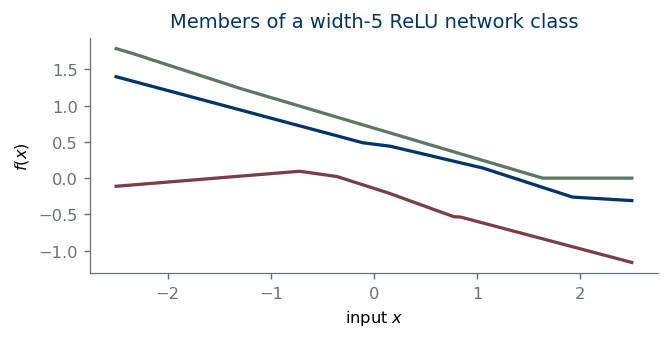

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/network-functions.pdf')

In [22]:
# Functions represented by a one-hidden-layer fully connected network.  These
# are model-class members, not fitted Wage curves.
z_grid = np.linspace(-2.5, 2.5, 400)
fig, ax = plt.subplots(figsize=FULL_TALL)
for j, color in enumerate([BLUE, RED, GREEN]):
    local_rng = np.random.default_rng(SEED + j)
    width = 5
    a = local_rng.normal(size=width)
    w = local_rng.normal(size=width)
    b = local_rng.normal(size=width)
    values = (np.maximum(0, z_grid[:, None] * w + b) @ a) / 2.5
    ax.plot(z_grid, values, color=color)
ax.set(xlabel="input $x$", ylabel="$f(x)$", title="Members of a width-5 ReLU network class")
save(fig, OUT / "network-functions.pdf", OUT / "network-functions.svg")

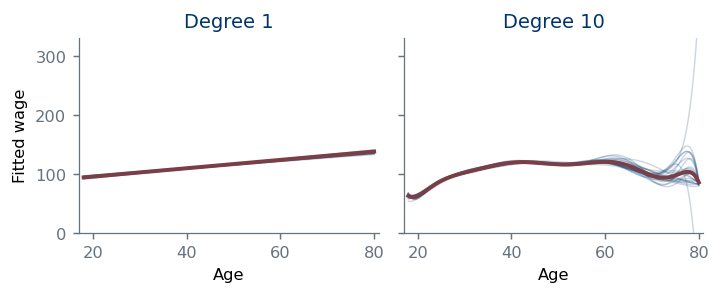

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/repeated-fits.pdf')

In [23]:
# Bootstrap the observed Wage rows to show procedure variability.
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, degree in zip(axes, [1, 10]):
    for _ in range(24):
        idx = rng.integers(0, len(wage), size=len(wage))
        fit = polynomial_fit(x_wage[idx], y_wage[idx], age_grid, degree)
        ax.plot(age_grid, fit, color=BLUE, alpha=0.20, linewidth=0.8)
    full_fit = polynomial_fit(x_wage, y_wage, age_grid, degree)
    ax.plot(age_grid, full_fit, color=RED, linewidth=2.2)
    ax.set(title=f"Degree {degree}", xlabel="Age", xlim=(17, 81), ylim=(0, 330))
axes[0].set_ylabel("Fitted wage")
fig.tight_layout(w_pad=0.75)
save(fig, OUT / "repeated-fits.pdf", OUT / "repeated-fits.svg")

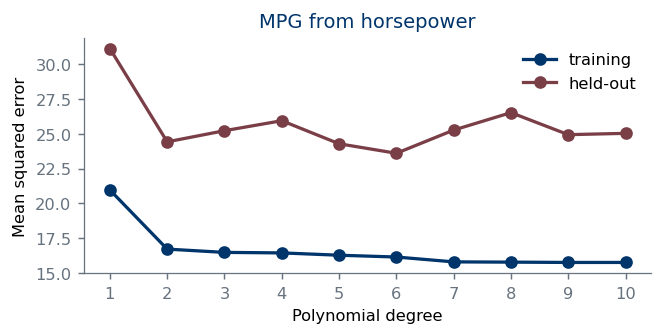

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/complexity-errors.pdf')

In [24]:
# A real held-out comparison on Auto: polynomial horsepower models for MPG.
auto = pd.read_csv('Auto.csv')
auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")
auto = auto.dropna(subset=["horsepower", "mpg"])
x_auto = auto["horsepower"].to_numpy(float)
y_auto = auto["mpg"].to_numpy(float)
order = rng.permutation(len(auto))
cut = int(0.70 * len(auto))
train, test = order[:cut], order[cut:]
degrees = np.arange(1, 11)
train_mse, test_mse = [], []
for degree in degrees:
    center, scale = x_auto[train].mean(), x_auto[train].std()
    coef = np.polyfit((x_auto[train] - center) / scale, y_auto[train], degree)
    train_pred = np.polyval(coef, (x_auto[train] - center) / scale)
    test_pred = np.polyval(coef, (x_auto[test] - center) / scale)
    train_mse.append(np.mean((y_auto[train] - train_pred) ** 2))
    test_mse.append(np.mean((y_auto[test] - test_pred) ** 2))

fig, ax = plt.subplots(figsize=FULL_TALL)
ax.plot(degrees, train_mse, color=BLUE, marker="o", label="training")
ax.plot(degrees, test_mse, color=RED, marker="o", label="held-out")
ax.set(xlabel="Polynomial degree", ylabel="Mean squared error", title="MPG from horsepower", xticks=degrees)
ax.legend()
save(fig, OUT / "complexity-errors.pdf", OUT / "complexity-errors.svg")

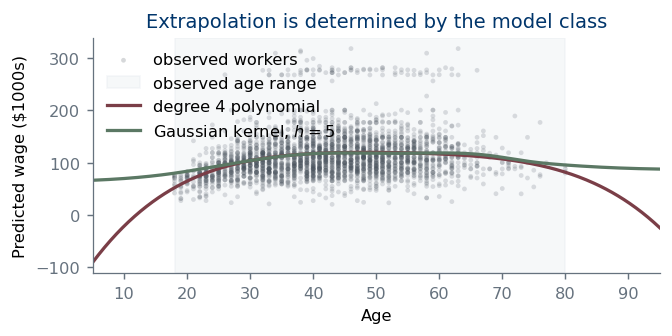

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/extrapolation.pdf')

In [25]:
# In-range and out-of-range behavior for two fitted rules.
grid_ext = np.linspace(5, 95, 380)
poly4 = polynomial_fit(x_wage, y_wage, grid_ext, 4)
kernel5 = kernel_fit(x_wage, y_wage, grid_ext, 5.0)
fig, ax = plt.subplots(figsize=FULL_TALL)
wage_points(ax, alpha=0.18)
ax.axvspan(18, 80, color=RULE, alpha=0.22, label="observed age range")
ax.plot(grid_ext, poly4, color=RED, label="degree 4 polynomial")
ax.plot(grid_ext, kernel5, color=GREEN, label="Gaussian kernel, $h=5$")
ax.set(xlabel="Age", ylabel="Predicted wage ($1000s)", title="Extrapolation is determined by the model class", xlim=(5, 95))
ax.legend(loc="upper left")
save(fig, OUT / "extrapolation.pdf", OUT / "extrapolation.svg")

Wage rows: 3000; age range: 18--80
Local-constant estimate at age 40, h=5: 117.15
Auto rows after cleaning: 392
Best held-out polynomial degree: 6
local average at age 40 with h=5: 118.5, 969 of 3000 points


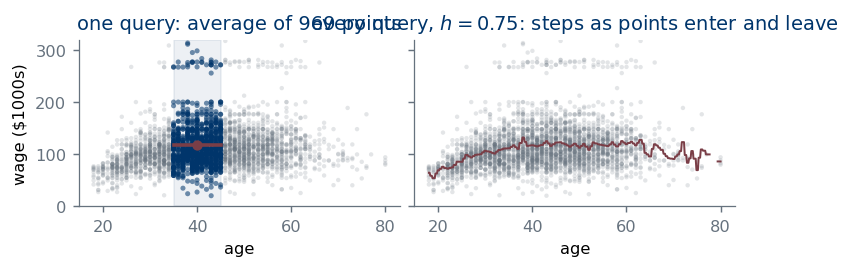

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/local-average.pdf')

In [26]:
print(f"Wage rows: {len(wage)}; age range: {x_wage.min():.0f}--{x_wage.max():.0f}")
print(f"Local-constant estimate at age {x0:.0f}, h={h:.0f}: {local_mean:.2f}")
print(f"Auto rows after cleaning: {len(auto)}")
print(f"Best held-out polynomial degree: {degrees[int(np.argmin(test_mse))]}")


def local_average_figure():
    """The naive local average: a hard-edged neighborhood around one query."""
    x0, h = 40.0, 5.0
    inside = np.abs(x_wage - x0) <= h
    est = y_wage[inside].mean()
    fig, axes = plt.subplots(1, 2, figsize=(FULL[0], 1.95), sharey=True)
    # Left: one query, its neighborhood, its average.
    ax = axes[0]
    ax.scatter(x_wage[~inside], y_wage[~inside], s=6, color=MUTED, alpha=.18,
               edgecolors="none", rasterized=True)
    ax.scatter(x_wage[inside], y_wage[inside], s=8, color=BLUE, alpha=.55,
               edgecolors="none", rasterized=True)
    ax.axvspan(x0 - h, x0 + h, color=BLUE, alpha=.07)
    ax.plot([x0 - h, x0 + h], [est, est], color=RED, linewidth=2)
    ax.scatter([x0], [est], color=RED, s=22, zorder=5)
    ax.set(xlabel="age", ylabel="wage (\\$1000s)", ylim=(0, 320),
           title=f"one query: average of {inside.sum()} points")
    # Right: repeating it at every query gives a step function.
    # A narrower window makes the hard edge visible: at h=5 each neighbourhood
    # holds ~500 rows and the steps are far too small to see.
    h2 = 0.75
    grid = np.linspace(x_wage.min(), x_wage.max(), 400)
    curve = np.array([y_wage[np.abs(x_wage - g) <= h2].mean()
                      if np.any(np.abs(x_wage - g) <= h2) else np.nan for g in grid])
    ax = axes[1]
    ax.scatter(x_wage, y_wage, s=6, color=MUTED, alpha=.18, edgecolors="none",
               rasterized=True)
    ax.plot(grid, curve, color=RED, linewidth=1.1)
    ax.set(xlabel="age", ylim=(0, 320),
           title=f"every query, $h={h2}$: steps as points enter and leave")
    fig.tight_layout(pad=0.3, w_pad=0.5)
    print(f"local average at age {x0:.0f} with h={h:.0f}: {est:.1f}, "
          f"{inside.sum()} of {len(x_wage)} points")
    return save(fig, OUT / "local-average.pdf", OUT / "local-average.svg")

local_average_figure()

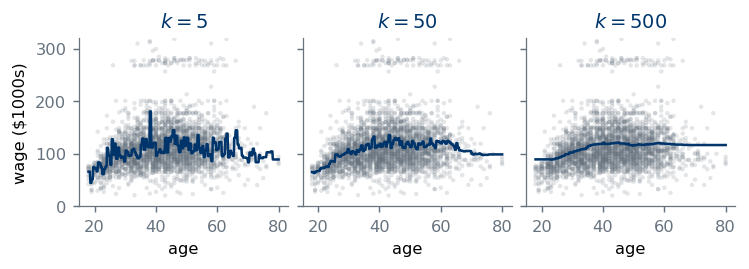

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/knn-fits.pdf')

In [27]:
def knn_figure():
    """k-nearest-neighbour regression at three values of k."""
    grid = np.linspace(x_wage.min(), x_wage.max(), 400)
    order = np.argsort(np.abs(grid[:, None] - x_wage[None, :]), axis=1)
    fig, axes = plt.subplots(1, 3, figsize=(FULL[0], 1.95), sharey=True)
    for ax, k in zip(axes, [5, 50, 500]):
        curve = y_wage[order[:, :k]].mean(axis=1)
        ax.scatter(x_wage, y_wage, s=6, color=MUTED, alpha=.18, edgecolors="none",
                   rasterized=True)
        ax.plot(grid, curve, color=BLUE, linewidth=1.4)
        ax.set(xlabel="age", ylim=(0, 320), title=f"$k={k}$")
    axes[0].set_ylabel("wage (\\$1000s)")
    fig.tight_layout(pad=0.3, w_pad=0.5)
    return save(fig, OUT / "knn-fits.pdf", OUT / "knn-fits.svg")

knn_figure()

curse: p = [1, 2, 3, 4, 5, 10, 20]
  knn    [np.float64(0.011), np.float64(0.034), np.float64(0.08), np.float64(0.139), np.float64(0.186), np.float64(0.38), np.float64(0.545)]
  linear [np.float64(0.029), np.float64(0.03), np.float64(0.032), np.float64(0.033), np.float64(0.035), np.float64(0.044), np.float64(0.075)]
  knn MSE grows 51.4x from p=1 to p=20; linear 2.6x


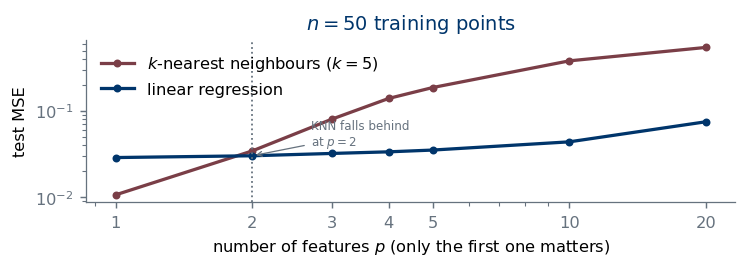

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/06-nonlinear-regression/curse-knn.pdf')

In [28]:
def curse_knn_figure():
    """KNN against linear regression as noise predictors are added.

    Follows ISL Figure 3.20: the response depends only on the first feature, and
    the extra features are pure noise.  Linear regression barely notices them;
    KNN degrades sharply, because with a fixed n the neighbours of a query stop
    being near it.  This replaces an abstract unit-cube volume calculation.
    """
    gen = np.random.default_rng(SEED)
    n_train, n_test, reps = 50, 500, 60
    dims = [1, 2, 3, 4, 5, 10, 20]
    lin_mse, knn_mse = [], []
    for p in dims:
        lin_r, knn_r = [], []
        for _ in range(reps):
            Xtr = gen.uniform(-1, 1, (n_train, p))
            Xte = gen.uniform(-1, 1, (n_test, p))
            f = lambda X: np.sin(2.0 * X[:, 0]) + 0.3 * X[:, 0]   # depends on x1 only
            ytr = f(Xtr) + 0.2 * gen.standard_normal(n_train)
            yte = f(Xte)
            # least squares with an intercept
            A = np.column_stack([np.ones(n_train), Xtr])
            beta, *_ = np.linalg.lstsq(A, ytr, rcond=None)
            pred_lin = np.column_stack([np.ones(n_test), Xte]) @ beta
            lin_r.append(np.mean((yte - pred_lin) ** 2))
            # k-nearest neighbours, k = 5
            d = np.linalg.norm(Xte[:, None, :] - Xtr[None, :, :], axis=2)
            idx = np.argsort(d, axis=1)[:, :5]
            pred_knn = ytr[idx].mean(axis=1)
            knn_r.append(np.mean((yte - pred_knn) ** 2))
        lin_mse.append(np.mean(lin_r)); knn_mse.append(np.mean(knn_r))
    fig, ax = plt.subplots(figsize=(FULL[0], 1.95))
    # Log scale on both axes: on a linear y-axis the least-squares curve is
    # pinned to zero and the crossover at small p -- the whole point -- is
    # invisible.
    ax.plot(dims, knn_mse, "o-", color=RED, markersize=3.4, label="$k$-nearest neighbours ($k=5$)")
    ax.plot(dims, lin_mse, "o-", color=BLUE, markersize=3.4, label="linear regression")
    cross = next((d for d, a, b in zip(dims, knn_mse, lin_mse) if a > b), None)
    if cross is not None:
        ax.axvline(cross, color=MUTED, linestyle=":", linewidth=1)
        ax.annotate(f"KNN falls behind\nat $p={cross}$", xy=(cross, lin_mse[dims.index(cross)]),
                    xytext=(cross * 1.35, min(lin_mse) * 1.4), color=MUTED, fontsize=6.6,
                    arrowprops=dict(arrowstyle="->", color=MUTED, lw=.7))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set(xlabel="number of features $p$ (only the first one matters)",
           ylabel="test MSE", title=f"$n={n_train}$ training points")
    ax.set_xticks(dims); ax.set_xticklabels([str(d) for d in dims])
    ax.legend(framealpha=0, loc="upper left")
    fig.tight_layout(pad=0.3)
    print("curse: p =", dims)
    print("  knn   ", [round(v, 3) for v in knn_mse])
    print("  linear", [round(v, 3) for v in lin_mse])
    print(f"  knn MSE grows {knn_mse[-1]/knn_mse[0]:.1f}x from p=1 to p=20; "
          f"linear {lin_mse[-1]/lin_mse[0]:.1f}x")
    return save(fig, OUT / "curse-knn.pdf", OUT / "curse-knn.svg")

curse_knn_figure()